# Тема 2. Визуальный анализ данных

Визуализация — это не просто «красивые картинки для отчётов». В ML она используется на каждом этапе работы:

- **Знакомство с данными.** Прежде чем строить модели, нужно понять, что вообще перед нами: какие распределения, есть ли выбросы, есть ли очевидные паттерны.
- **Отбор признаков.** Графики помогают увидеть, какие переменные связаны с целевой, а какие — нет.
- **Интерпретация модели.** Результаты и ошибки модели гораздо проще осмыслить визуально.

Невероятно, сколько всего можно понять из простых графиков — ещё до того, как запущена первая модель.

В этом ноутбуке мы будем работать с библиотеками `pandas`, `matplotlib` и `seaborn`.

### Содержание
1. [Датасет](#1.-Датасет)
2. [Одномерный анализ](#2.-Одномерный-анализ)
    - 2.1 [Количественные признаки](#2.1-Количественные-признаки)
    - 2.2 [Категориальные и бинарные признаки](#2.2-Категориальные-и-бинарные-признаки)
3. [Многомерный анализ](#3.-Многомерный-анализ)
    - 3.1 [Количественный vs. Количественный](#3.1-Количественный-vs.-Количественный)
    - 3.2 [Количественный vs. Категориальный](#3.2-Количественный-vs.-Категориальный)
    - 3.3 [Категориальный vs. Категориальный](#3.3-Категориальный-vs.-Категориальный)
4. [Практика: Titanic](#4.-Практика:-Titanic)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()  # применяет стиль seaborn ко всем графикам matplotlib

# SVG — чёткие векторные графики в ноутбуке
%config InlineBackend.figure_format = 'svg'

---
## 1. Датасет

Работаем с данными телеком-оператора: 3333 клиента, признаки об их поведении, и целевая переменная `Churn` — ушёл ли клиент.


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/harshbg/Telecom-Churn-Data-Analysis/refs/heads/master/Telecom%20Churn.csv")
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


Описание признаков:

| Признак | Описание | Тип |
|---|---|---|
| **State** | Штат клиента | Категориальный |
| **Account length** | Длительность договора (дней) | Количественный |
| **Area code** | Код региона | Категориальный (хотя число!) |
| **International plan** | Международный план (Yes/No) | Бинарный |
| **Voice mail plan** | Голосовая почта (Yes/No) | Бинарный |
| **Number vmail messages** | Количество голосовых сообщений | Количественный |
| **total day/eve/night minutes** | Суммарные минуты звонков по времени суток | Количественный |
| **total day/eve/night calls** | Количество звонков по времени суток | Количественный |
| **total day/eve/night charge** | Стоимость звонков по времени суток | Количественный |
| **total intl minutes/calls/charge** | Международные звонки | Количественный |
| **Customer service calls** | Звонки в поддержку | Порядковый |
| **Churn** | Ушёл ли клиент? | **Целевая переменная** (бинарная) |

In [ ]:
df.shape

In [ ]:
df.info()

---
## 2. Одномерный анализ

*Одномерный* анализ (univariate) — смотрим на каждый признак по отдельности, не думая о взаимосвязях.

Главный вопрос: **каково распределение значений этого признака?**

### 2.1 Количественные признаки

*Количественные* признаки — это числа, у которых есть порядок и смысл разности: длительность звонка, возраст, сумма чека.

#### Гистограмма

Самый простой способ посмотреть на распределение — гистограмма: разбиваем диапазон значений на интервалы (бины) одинаковой ширины и считаем, сколько наблюдений попало в каждый.

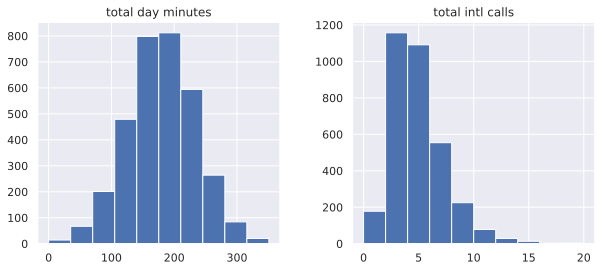

In [3]:
features = ["total day minutes", "total intl calls"]
df[features].hist(figsize=(10, 4));

Что видим:
- *total day minutes* — похоже на нормальное (гауссово) распределение: симметричный колокол.
- *total intl calls* — скошено вправо: большинство клиентов делают мало международных звонков, но есть хвост с высокими значениями.

Форма распределения важна: многие ML-алгоритмы неявно предполагают нормальность (линейная регрессия, LDA). Сильно скошенные признаки иногда стоит логарифмировать.

#### Оценка плотности (KDE)

Другой способ посмотреть на то же самое — *kernel density estimate* (KDE), сглаженная версия гистограммы. Её главное преимущество: результат не зависит от выбора ширины бинов.

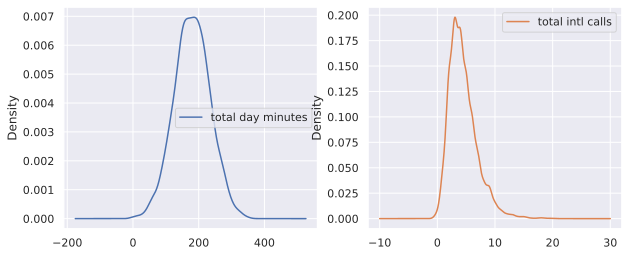

In [4]:
df[features].plot(
    kind="density", subplots=True, layout=(1, 2), sharex=False, figsize=(10, 4)
);

Seaborn умеет строить гистограмму и KDE вместе — удобно сравнивать:

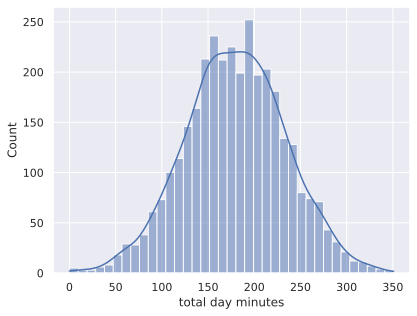

In [5]:
sns.histplot(df["total day minutes"], kde=True);

#### Box plot (ящик с усами)

Box plot — ещё один взгляд на то же распределение, но делает акцент на статистиках: медиане, квартилях и выбросах.

Как читать box plot:

```
    |----[=====|=====]-----|  o   o
         Q1   med  Q3         outliers
```

- **Ящик**: от $Q_1$ (25-й перцентиль) до $Q_3$ (75-й перцентиль) — здесь лежит середина данных
- **Линия внутри**: медиана ($Q_2$, 50-й перцентиль)
- **Усы**: от $Q_1 - 1.5 \cdot IQR$ до $Q_3 + 1.5 \cdot IQR$, где $IQR = Q_3 - Q_1$
- **Точки за усами**: выбросы (outliers)

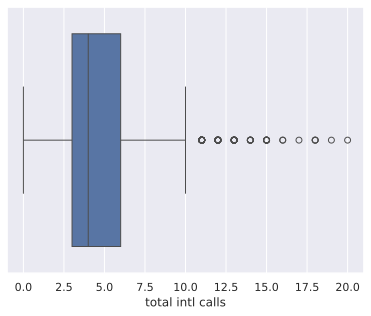

In [6]:
sns.boxplot(x="total intl calls", data=df);

Видно, что большое количество международных звонков встречается редко — это выбросы правее правого уса.

Числовые статистики можно получить через `describe()`:

In [7]:
df[features].describe()

,total day minutes,total intl calls
count,3333.000000,3333.000000
mean,179.775098,4.479448
std,54.467389,2.461214
min,0.000000,0.000000
25%,143.700000,3.000000
50%,179.400000,4.000000
75%,216.400000,6.000000
max,350.800000,20.000000


#### Violin plot

Violin plot — гибрид box plot и KDE: показывает и форму распределения, и квартили одновременно.

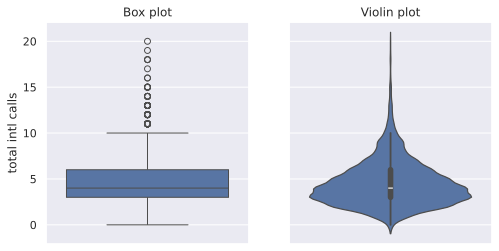

In [8]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
sns.boxplot(data=df["total intl calls"], ax=axes[0])
axes[0].set_title("Box plot")
sns.violinplot(data=df["total intl calls"], ax=axes[1])
axes[1].set_title("Violin plot");

В данном случае violin plot не добавляет много нового — и так видно, что распределение скошено вправо. Но на других данных он может быть информативнее box plot, особенно когда распределение мультимодальное (несколько «горбов»).

> **Ваш черёд.** Постройте box plot и гистограмму для признака `Account length`. Как выглядит распределение?

In [ ]:
# Ваш код здесь

### 2.2 Категориальные и бинарные признаки

*Категориальные* признаки принимают конечный набор значений, каждое из которых обозначает некоторую группу. *Бинарные* — частный случай: ровно два значения (Yes/No, True/False). *Порядковые* (ordinal) — категориальные со смыслом порядка (1-й класс, 2-й класс, ...).

#### Таблица частот

Посмотрим на распределение целевой переменной:

In [9]:
df["churn"].value_counts()

,count
churn,
False,2850
True,483


Данные **несбалансированы**: лояльных клиентов ~86%, ушедших ~14%. Это типичная ситуация в задачах оттока. Если просто предсказывать «никто не уйдёт», получим 86% точности — но модель будет бесполезной. Нужно будет учитывать это при оценке качества.

#### Bar plot (столбчатая диаграмма)

Столбчатая диаграмма — это, по сути, визуальная версия таблицы частот.

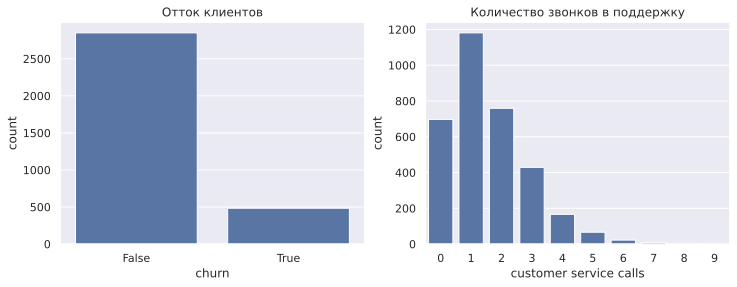

In [10]:
_, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="churn", data=df, ax=axes[0])
axes[0].set_title("Отток клиентов")

sns.countplot(x="customer service calls", data=df, ax=axes[1])
axes[1].set_title("Количество звонков в поддержку");

Несколько важных отличий bar plot от гистограммы:
1. **Гистограмма** — для числовых переменных, **bar plot** — для категориальных.
2. Ось X у гистограммы — числовая шкала; у bar plot — список категорий (порядок можно менять).
3. У гистограммы ширина бина имеет смысл; у bar plot столбцы — просто метки.

График с `Customer service calls` намекает: большинство клиентов решают вопрос за 1–3 звонка. Но нас интересует хвост — там может скрываться большая доля оттока. Это гипотеза — проверим её позже.

> **Ваш черёд.** Постройте bar plot для `International plan`. Сколько клиентов подключили международный план?

In [ ]:
# Ваш код здесь

---
## 3. Многомерный анализ

*Многомерный* анализ (multivariate) — ищем **взаимосвязи** между признаками. Именно здесь начинается настоящий разведочный анализ данных для ML: какие признаки связаны с целевой переменной? Есть ли мультиколлинеарность?

### 3.1 Количественный vs. Количественный

#### Корреляционная матрица

Корреляция Пирсона показывает линейную связь между двумя числовыми переменными: от −1 (обратная) до +1 (прямая), 0 — нет линейной связи.

Некоторые ML-алгоритмы (например, линейная регрессия) плохо работают, когда признаки сильно коррелируют между собой — это называется **мультиколлинеарностью**. Heatmap корреляционной матрицы — быстрый способ это обнаружить.

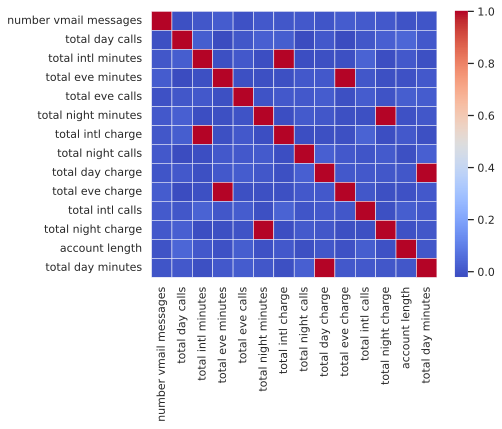

In [11]:
# Отберём только числовые столбцы, уберём категориальные по смыслу
numerical = list(
    set(df.columns)
    - {"state", "international plan", "voice mail plan", "area code", "churn", "customer service calls", "phone number"}
)

corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5);

Хорошо видно несколько ярко-красных блоков. Это признаки вроде `total day charge` и `total day minutes` — цена напрямую вычисляется из минут, поэтому корреляция = 1. Такие признаки называют **зависимыми** или **производными** — они не несут новой информации.

Уберём их:

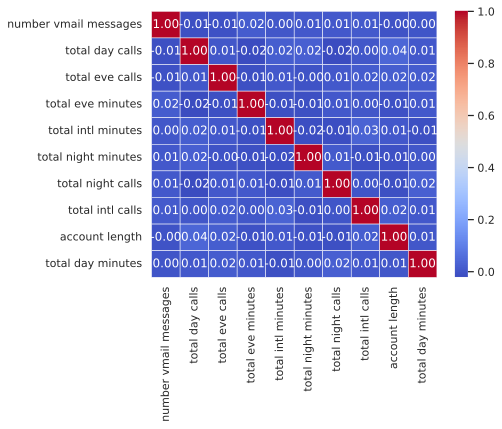

In [12]:
numerical = list(
    set(numerical)
    - {"total day charge", "total eve charge", "total night charge", "total intl charge"}
)

corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5);

Теперь сильных корреляций нет — это хорошо. Оставшиеся признаки относительно независимы.

#### Диаграмма рассеяния (Scatter plot)

Scatter plot показывает пары значений двух числовых переменных как точки на плоскости.

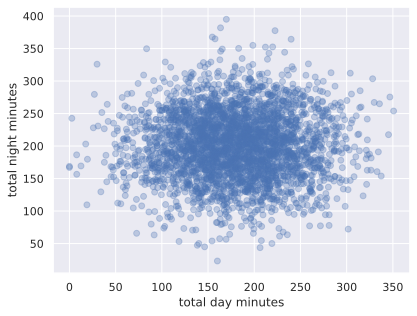

In [13]:
plt.scatter(df["total day minutes"], df["total night minutes"], alpha=0.3)
plt.xlabel("total day minutes")
plt.ylabel("total night minutes");

«Эллипсообразное» облако точек, ориентированное вдоль осей — признак отсутствия корреляции. Если бы признаки коррелировали, облако было бы вытянуто по диагонали.

Seaborn добавляет гистограммы по краям — сразу видно и совместное, и маргинальные распределения:

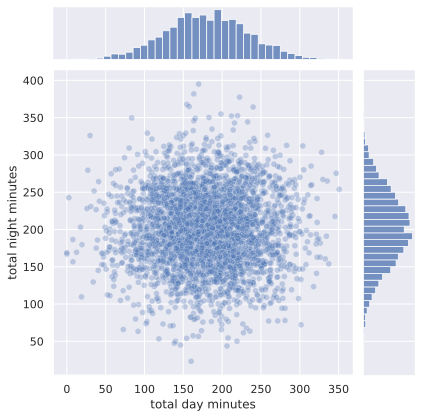

In [14]:
sns.jointplot(x="total day minutes", y="total night minutes", data=df, kind="scatter", alpha=0.3);

In [ ]:
# KDE-версия того же графика — сглаженная «тепловая карта» совместного распределения
sns.jointplot(x="total day minutes", y="total night minutes", data=df, kind="kde", color="g");

#### Матрица диаграмм рассеяния (Pairplot)

Когда признаков несколько, удобно посмотреть на все пары сразу. По диагонали — распределение каждого признака, вне диагонали — scatter plots для каждой пары.

In [15]:
# PNG быстрее рендерится для сложных графиков
%config InlineBackend.figure_format = 'png'
sns.pairplot(df[numerical]);

Output hidden; open in https://colab.research.google.com to view.

In [16]:
%config InlineBackend.figure_format = 'svg'

На таком графике сразу видны структурные закономерности: нормальные распределения на диагонали, отсутствие выраженных паттернов на scatter plots — всё говорит о том, что признаки относительно независимы.

> **Ваш черёд.** Выберите два признака, которые по вашей интуиции должны быть независимы, и два, которые могут быть связаны. Постройте для них scatter plots.

In [ ]:
# Ваш код здесь

### 3.2 Количественный vs. Категориальный

Это сердце разведочного анализа для задач классификации: **как числовые признаки ведут себя в разных классах?**

Раскрасим scatter plot по значению `Churn`:

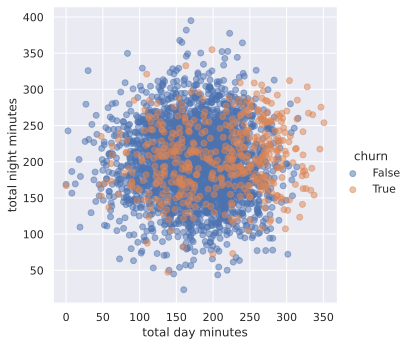

In [25]:
sns.lmplot(
    x="total day minutes", y="total night minutes",
    data=df, hue="churn", fit_reg=False, scatter_kws={"alpha": 0.5}
);

Оранжевые точки (ушедшие) немного тяготеют к правому верхнему углу — такие клиенты чаще звонят и днём, и ночью. Но граница нечёткая, на основе только этих двух признаков разделить классы сложно.

#### Box plots по всем признакам

Очень эффективный приём — построить box plot каждого признака, разбитый по целевой переменной. Сразу видно, какие признаки «различают» классы:

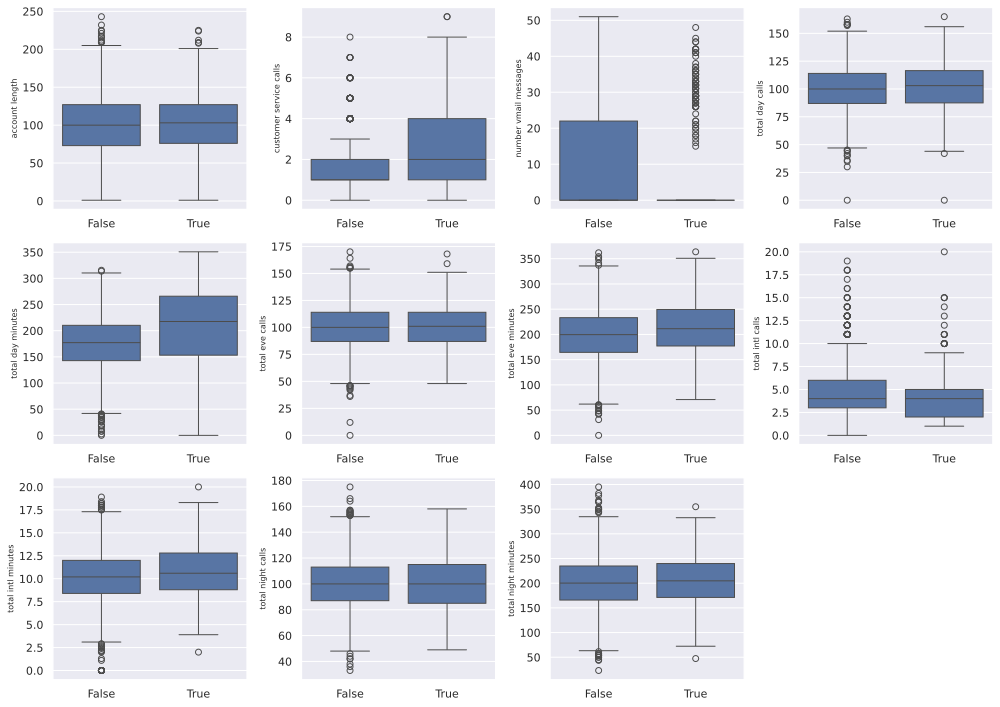

In [17]:
# Добавим Customer service calls — он порядковый, но можно анализировать как числовой
numerical_with_cs = numerical + ["customer service calls"]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 10))

for idx, feat in enumerate(sorted(numerical_with_cs)):
    ax = axes[idx // 4, idx % 4]
    sns.boxplot(x="churn", y=feat, data=df, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(feat, fontsize=8)

# Убираем лишние пустые оси
for idx in range(len(numerical_with_cs), 12):
    axes[idx // 4, idx % 4].set_visible(False)

fig.tight_layout();

Уже на этом графике можно сделать важные выводы. Наибольшее расхождение между ушедшими и оставшимися клиентами заметно у трёх признаков: **total day minutes**, **Customer service calls** и **Number vmail messages**. Именно они, скорее всего, окажутся важными в модели — и позже, когда будем строить деревья решений, убедимся в этом.

Рассмотрим `total day minutes` подробнее:

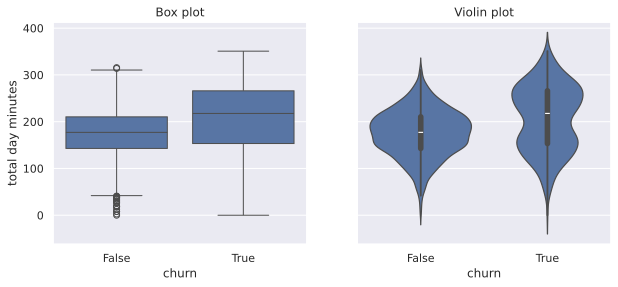

In [18]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

sns.boxplot(x="churn", y="total day minutes", data=df, ax=axes[0])
axes[0].set_title("Box plot")

sns.violinplot(x="churn", y="total day minutes", data=df, ax=axes[1])
axes[1].set_title("Violin plot");

**Интересное наблюдение:** клиенты, которые ушли, в среднем говорят по телефону *больше*. Возможная гипотеза: они недовольны тарифом — при высоком потреблении он невыгоден. Компании стоит рассмотреть скидки для активных пользователей. Конечно, это требует дополнительного экономического анализа.

#### catplot — количественный признак в разрезе двух категориальных

Иногда нужно посмотреть сразу на два среза: например, как `total day minutes` зависит от `Churn` при разном количестве звонков в поддержку.

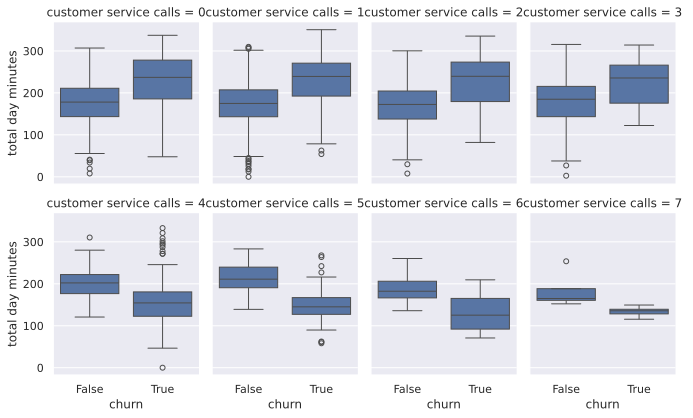

In [19]:
sns.catplot(
    x="churn",
    y="total day minutes",
    col="customer service calls",
    data=df[df["customer service calls"] < 8],
    kind="box",
    col_wrap=4,
    height=3,
    aspect=0.8,
);

При 1–3 звонках в поддержку ушедшие клиенты действительно говорят больше. Но начиная с 4 звонков это различие исчезает — там количество минут перестаёт быть главным фактором. По всей видимости, при многих жалобах клиент уходит вне зависимости от объёма использования.

> **Ваш черёд.** Постройте box plot для `Customer service calls` по группам `Churn`. Что можно сказать?

In [ ]:
# Ваш код здесь

### 3.3 Категориальный vs. Категориальный

#### Countplot с `hue`

Самый простой способ — добавить цветовое кодирование к bar plot через параметр `hue`:

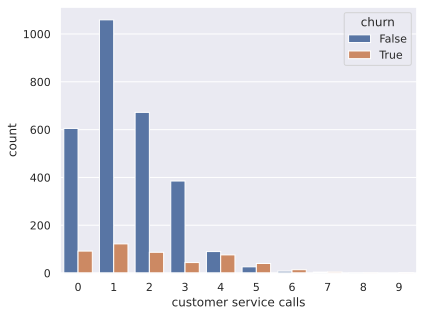

In [20]:
sns.countplot(x="customer service calls", hue="churn", data=df);

**Наблюдение:** при 1–3 звонках в поддержку доля ушедших мала. После 4 звонков она резко возрастает. Это очень чёткий сигнал — `Customer service calls` будет сильным признаком.

Посмотрим на бинарные признаки:

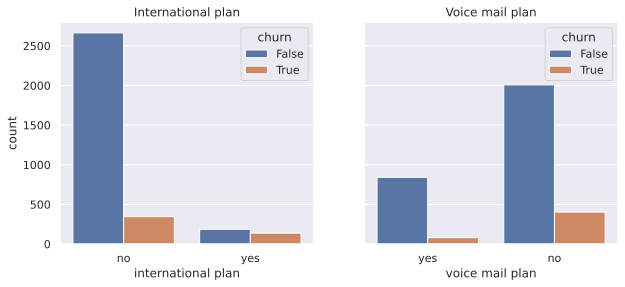

In [21]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

sns.countplot(x="international plan", hue="churn", data=df, ax=axes[0])
axes[0].set_title("International plan")

sns.countplot(x="voice mail plan", hue="churn", data=df, ax=axes[1])
axes[1].set_title("Voice mail plan");

**Наблюдение:**
- **International plan = Yes**: доля оттока сильно выше (~42% против ~11%). Это мощный признак.
- **Voice mail plan**: похожего эффекта не видно.

#### Таблица сопряжённости (Cross tabulation)

Классический инструмент из статистики — позволяет увидеть распределение одной переменной при каждом значении другой:

In [22]:
pd.crosstab(df["international plan"], df["churn"])

churn,False,True
international plan,,
no,2664,346
yes,186,137


In [23]:
# Нормированная версия — доли по строкам
pd.crosstab(df["international plan"], df["churn"], normalize="index").round(3)

churn,False,True
international plan,,
no,0.885,0.115
yes,0.576,0.424


Теперь в числах: среди клиентов *с* международным планом уходит **42%**, а без него — только **11%**. Такую разницу нельзя игнорировать — это один из самых сильных сигналов в датасете.

Посмотрим, есть ли региональные эффекты:

In [24]:
churn_by_state = (
    df.groupby("state")["churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn rate", "count": "N"})
    .sort_values("churn rate", ascending=False)
)
churn_by_state.head(10)

,churn rate,N
state,,
CA,0.264706,34
NJ,0.264706,68
TX,0.250000,72
MD,0.242857,70
SC,0.233333,60
MI,0.219178,73
MS,0.215385,65
WA,0.212121,66
NV,0.212121,66


На первый взгляд, некоторые штаты имеют очень высокий отток (NJ, CA). Но посмотрите на колонку N — там всего 30–50 клиентов. **Малый размер выборки делает выводы ненадёжными**: это может быть случайный шум, а не реальный эффект. Всегда проверяйте, сколько наблюдений стоит за цифрой.

---
## 4. Практика: Titanic

Данные о пассажирах «Титаника». Задача — понять, какие признаки влияли на выживаемость.

Целевая переменная: `Survived` (1 — выжил, 0 — нет).

In [26]:
train_df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv", index_col="PassengerId")
train_df.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [27]:
train_df.describe(include="all")

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


Видно, что в `Cabin` очень много пропусков — уберём этот столбец, а затем удалим строки с оставшимися пропусками.

In [ ]:
train_df = train_df.drop("Cabin", axis=1).dropna()
train_df.shape

### Задание 1
Постройте матрицу диаграмм рассеяния (`pairplot`) для признаков `Age`, `Fare`, `SibSp`, `Parch` и `Survived`.

In [ ]:
# Ваш код здесь

### Задание 2
Как цена билета (`Fare`) зависит от класса каюты (`Pclass`)? Постройте boxplot.

<Axes: xlabel='Pclass', ylabel='Fare'>

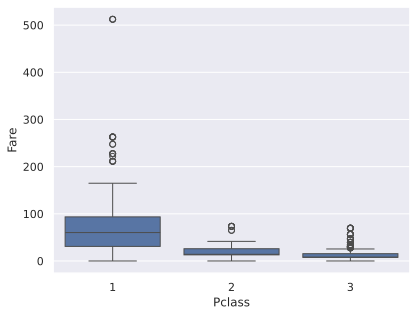

In [30]:
# Ваш код здесь
sns.boxplot(train_df, y='Fare',x='Pclass')

### Задание 3
Постройте тот же boxplot, но ограничьте `Fare` значениями ниже 95-го перцентиля (это уберёт выбросы и сделает график читаемее).

*Подсказка:* `train_df["Fare"].quantile(0.95)`

In [ ]:
# Ваш код здесь

### Задание 4
Как выживаемость зависит от пола пассажира? Используйте `countplot` с аргументом `hue="Survived"`.

Дополнительно: посмотрите то же самое в разрезе `Pclass`.

In [ ]:
# Ваш код здесь

### Задание 5
Как распределялась цена билета (`Fare`) у выживших и у погибших? Постройте `boxplot`.

Ограничьте `Fare < 500`, чтобы убрать экстремальные выбросы.

In [ ]:
# Ваш код здесь

### Задание 6
Зависит ли выживаемость от возраста?

Проверьте гипотезу: молодые пассажиры (< 30 лет) выживали чаще, чем пожилые (> 55 лет).

Создайте новый столбец `age_cat`:
- `1` — моложе 30
- `2` — от 30 до 55
- `3` — старше 55

Затем постройте `countplot` с `hue="Survived"` по этой переменной.

In [ ]:
# Ваш код здесь# Подсказка: используйте .apply() с lambda-функцией

---
## Полезные ресурсы

- [Документация seaborn](https://seaborn.pydata.org/api.html) — галерея с примерами очень помогает
- [Галерея matplotlib](https://matplotlib.org/stable/gallery/index.html)
- [Выбор нужного графика](https://www.data-to-viz.com/) — from Data to Viz, отличный справочник